In [2]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import os
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
# from matplotlib.ticker import FormatStrFormatter



## Get split half reliability from TIMIT data

In [3]:
path_to_human_data = Path('/mindhive/mcdermott/www/imgriff/msjspsych/')
# !ls {path_to_human_data}
# full paths to .json files 
human_fnames = list(path_to_human_data.glob("cocktail_party_cue_duration_pilot/data/*.json"))

# import vocab dict for matching audio & responses 
# word_and_speaker_encodings = pickle.load( open("/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
# # ix_to_word_map = {v:k for k,v in class_map.items()}
# class_map = word_and_speaker_encodings['word_idx_to_word']
len(human_fnames)

49

In [4]:
## Get all subject data into one df for analysis

def get_part_df(fname):
    part_data = json.load(open(fname, 'r'))
    # print(f"{fname.stem} success {part_data[0]['success']}")
    part_df = pd.DataFrame.from_records(part_data)
    ## Forward fill stim presentation entry to word response entry
    responses = part_df.loc[part_df.trial_type.isin(['audio-keyboard-response','dictionary-text']), ['trial_index', 'stimulus']]
    responses = responses.ffill()
    part_df.loc[part_df['trial_index'].isin(responses["trial_index"].values), 'stimulus'] = responses.stimulus
    return part_df

dfs = []
for fname in human_fnames:
    try:
        dfs.append(get_part_df(fname))
    except Exception as e:
        print(e)
        print(fname)
    
# results_df = pd.concat([get_part_df(fname) for fname in human_fnames], axis=0, ignore_index=True)
results_df = pd.concat(dfs)

## Filter for those who passed headphone check 

results_df = results_df[results_df.hc_passed == True]


## Add snr and condition names as columns - unpack from file code in file names 

import re
# get cond name map
map_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/human_pilot_cue_duration_cond_map.pkl')
with open(map_path, 'rb') as handle:
    stim_cond_map = pickle.load(handle)

stim_cond_map = {f"condition_{k}": v for k,v in stim_cond_map.items()}

## Map wav str to stim_type using condition dict
def get_stim_snr_and_cond(stim_str, stim_cond_map=stim_cond_map):
    condition, cue_dur = None,  None 
    if isinstance(stim_str, str) and not stim_str.startswith('<'):
        cond_str = re.search("condition_(-?\d+)", stim_str)
        if cond_str:
            cond_str = cond_str.group(0)
            cue_dur = stim_cond_map[cond_str]
            condition = 'trial'
        elif 'catch' in stim_str:
            condition = 'catch_trial'
            cue_dur = 2
    return cue_dur, condition

# add as columns 
results_df['cue_dur'], results_df['condition'] = zip(*results_df['stimulus'].apply(get_stim_snr_and_cond))

# cut down df to only have trial answers (remove other meta data)
expmnt_trial_str = "dictionary-text"
trial_results = results_df[results_df.trial_type == expmnt_trial_str]

# Convert condition names to  readable format 
# test_condition_dict = {'music':"background_musdb18hq",
#                        "babble":"background_cv08talkerbabble",
#                        "stationary": "background_issnstationary",
#                        "modulated": "background_issnfestenplomp",
#                        "audioset": "background_audioset",
#                        "natural scene": "background_ieeeaaspcasa",
#                        "clean": "SILENCE"}

# condition_map = {v:k for k,v in test_condition_dict.items()}
# trial_results['condition'] = trial_results['condition'].replace(condition_map)


# screen based on completion 
version = 0 
trial_results = trial_results[trial_results.id_version == version]

total_trials = 87

full_run_subjects = [subj_id for subj_id, did_all_trials in (trial_results.groupby('id_subject').condition.count() >= total_trials).items() if did_all_trials == True]
trial_results = trial_results[trial_results.id_subject.isin(full_run_subjects)]

# Add accuracy 
trial_results['accuracy'] = (trial_results['response_str'] == trial_results['correct_response']).astype('int')


Expecting ':' delimiter: line 1 column 83855 (char 83854)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_614f3ad3e0837475bb79d175.json
Unterminated string starting at: line 1 column 71919 (char 71918)
/mindhive/mcdermott/www/imgriff/msjspsych/cocktail_party_cue_duration_pilot/data/subj_6160717242827a64a55d99ad.json


In [5]:
trial_results.id_subject.unique()

array(['63658b4da2cc06a1cf53887c', '5c4068a67f81e900012b281e',
       '601c277aabe00c6bc759bf69', '63d842d3e9626bd5fe5c17b1',
       '65b3c1c066f67784312a946b', '57b89a091e1cd400013e46fd',
       '6434883fbd767c0954ada3a2', '64157c7105837695ad52b091',
       '5f1f680d643ad300084c7e93', '5c575a94a1c68a00018fd213',
       '65e72fad8b2c013b9008bd08', '62b9cf42a63194f71fc0a393'],
      dtype=object)

In [6]:
catch_trial_particiapnt_performance = trial_results[trial_results.condition == 'catch_trial'].groupby('id_subject').accuracy.mean()
catch_trial_particiapnt_performance

id_subject
57b89a091e1cd400013e46fd    1.000000
5c4068a67f81e900012b281e    1.000000
5c575a94a1c68a00018fd213    0.916667
5f1f680d643ad300084c7e93    0.833333
601c277aabe00c6bc759bf69    0.866667
62b9cf42a63194f71fc0a393    1.000000
63658b4da2cc06a1cf53887c    0.916667
63d842d3e9626bd5fe5c17b1    0.933333
64157c7105837695ad52b091    0.733333
6434883fbd767c0954ada3a2    0.933333
65b3c1c066f67784312a946b    0.933333
65e72fad8b2c013b9008bd08    1.000000
Name: accuracy, dtype: float64

In [7]:
print("N total participants ", len(catch_trial_particiapnt_performance))
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance >= 13/15].index
print("N good participants ", len(good_participants))

good_results = trial_results[trial_results.id_subject.isin(good_participants)]
analysis_df = good_results[(~good_results.condition.isnull()) & (~good_results.response_str.isna())]
analysis_df.groupby('id_subject').condition.count()


N total participants  12
N good participants  10


id_subject
57b89a091e1cd400013e46fd    95
5c4068a67f81e900012b281e    95
5c575a94a1c68a00018fd213    87
601c277aabe00c6bc759bf69    95
62b9cf42a63194f71fc0a393    95
63658b4da2cc06a1cf53887c    87
63d842d3e9626bd5fe5c17b1    95
6434883fbd767c0954ada3a2    95
65b3c1c066f67784312a946b    95
65e72fad8b2c013b9008bd08    95
Name: condition, dtype: int64

In [8]:


### Look at 1 talker sex conditions

manifest = pd.read_pickle("/om/user/imgriff/datasets/human_cue_duration_SWC_2024/manifest_w_transcripts.pdpkl")
manifest["base_trial"] = manifest.mixture_fn.apply(lambda x: x.as_posix().split('/')[-1]) 

## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifest to trial_results where trial_results.stimulus == manifest.base_str
analysis_df['base_trial'] = analysis_df.stimulus.apply(lambda x: x.split('/')[-1])

# analysis_df = pd.merge(analysis_df,
#                         manifest[['base_trial', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word']],
#                                     left_on='base_trial', right_on='base_trial', how='left')
# analysis_df['confusions'] = (analysis_df.response_str == analysis_df.distractor_word).astype('int')


analysis_df = pd.merge(analysis_df,
                        manifest[['base_trial', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcripts', 'distractor_transcripts']],
                                    left_on='base_trial', right_on='base_trial', how='left')
analysis_df['confusions'] = (analysis_df.response == analysis_df.distractor_word).astype('int')


# add adjusted accuracy and confusions 
target_words = analysis_df.response.values
target_transcripts = analysis_df.target_transcripts.values
distractor_transcripts = analysis_df.distractor_transcripts.values


adjusted_acc = np.array([int(target_word in target_transcript)
                            if not isinstance(target_transcript, float) else np.nan
                             for target_word, target_transcript in zip(target_words, target_transcripts)
                              ])

adjusted_confs = np.array([int(target_word in distractor_transcript)
                            if not isinstance(distractor_transcript, float) else np.nan
                             for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                              ])

analysis_df['adjusted_accuracy'] = adjusted_acc
analysis_df['adjusted_confusions'] = adjusted_confs

analysis_df['gender_cond'] = analysis_df['target_gender'].values == analysis_df['distractor_gender'].values
analysis_df['gender_cond'] = analysis_df['gender_cond'].replace({True: 'Same sex', False: 'Different sex'})

# get trial data excluding catch trials 


part_summary_df = (analysis_df[analysis_df['condition'] == 'trial'].groupby(['id_subject', "cue_dur"])
                     .agg({'adjusted_accuracy':['mean', 'sem', 'count'], 'adjusted_confusions':['mean', 'sem', 'count']})
                     .reset_index())

# part_summary_df['snr'] = part_summary_df['snr'].replace(np.inf, 6)
# part_summary_df['snr'] =  part_summary_df['snr'].replace("inf", 6)
# part_summary_df['snr'] = part_summary_df['snr'].astype('int')
# flatten multiindex 
part_summary_df.columns = ['_'.join(col).strip() for col in part_summary_df.columns.values]
# remove trailing underscore
part_summary_df.columns = [col[:-1] if col.endswith('_') else col for col in part_summary_df.columns.values]

# parts_to_keep = part_summary_df.groupby('id_subject').cue_dur.count() == 4
# part_summary_df = part_summary_df[part_summary_df.id_subject.isin()]



In [9]:
from tqdm.auto import tqdm
import scipy.stats as stats

np.random.seed(0)
n_parts = part_summary_df.id_subject.nunique()
max_split_size = n_parts // 2
# run power analysis computing split half reliability for each split size

conds = [0.25, 0.5 , 1.  , 2.]
unique_participants = part_summary_df.id_subject.unique()

split_half_reliabilities = []
n_boots = 10000
for k in tqdm(range(2, max_split_size+1)):
    for cond in tqdm(conds, leave=False):
        split_corrs = np.zeros(n_boots)
        cond_results = part_summary_df[part_summary_df.cue_dur == cond]
        for i in range(n_boots):
            # get group 1
            group_1_names = np.random.choice(unique_participants, k, replace=False)
            group_1 = cond_results[cond_results.id_subject.isin(group_1_names)].adjusted_accuracy_mean.values
            # get group 2
            group_2_names = np.random.choice(unique_participants[~np.isin(unique_participants, group_1_names)], k, replace=False)
            group_2 = cond_results[cond_results.id_subject.isin(group_2_names)].adjusted_accuracy_mean.values
            # get r
            r = stats.pearsonr(group_1, group_2).statistic 
            split_corrs[i] = r  
        # get condition mean and std
        mean_r = np.nanmean(split_corrs)
        std_err =  np.nanstd(split_corrs) / np.sqrt(n_boots) 
        corrected_mean = (2 * mean_r) / ( 1 + mean_r)
        corrected_error = (2 * std_err) / ( 1 + std_err)

        split_half_reliabilities.append({"k":k, "cue_dur":cond, "mean_cor":corrected_mean, "sem": corrected_error})

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/home/imgriff/.local/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

In [10]:
power_analysis_df = pd.DataFrame(split_half_reliabilities) 

# get snr and cond as separate columns
# power_analysis_df['cue_dur'] = power_analysis_df.cond.apply(lambda x: x.split('dB')[0].split('_')[-1])
# power_analysis_df['dist'] = power_analysis_df.cond.apply(lambda x: x.split('_')[0])

In [11]:
power_analysis_df


,k,cue_dur,mean_cor,sem
0,2,0.25,-0.215029,0.019709
1,2,0.50,-0.272967,0.019660
2,2,1.00,-0.172496,0.019740
3,2,2.00,-0.318001,0.019617
4,3,0.25,-0.272281,0.014029
5,3,0.50,-0.405678,0.013947
6,3,1.00,-0.267618,0.013710
7,3,2.00,-0.395249,0.013635
8,4,0.25,-0.565669,0.011714
9,4,0.50,-0.892963,0.010933


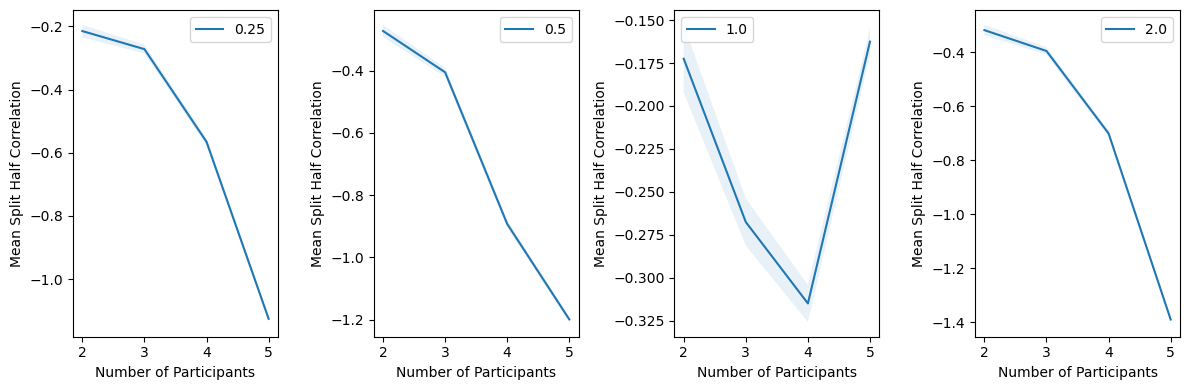

In [17]:
# plot 
fig, axs = plt.subplots(1,4, figsize=(12,4))
# axs = ax.flatten()
# make palette for snr

for s_ix, cue_dur in enumerate(power_analysis_df.cue_dur.unique()):

    cond_df = power_analysis_df[(power_analysis_df.cue_dur == cue_dur)]
    sns.lineplot(data=cond_df,
                    x='k', y='mean_cor',
                    # color=palette[p_ix],
                    ax=axs[s_ix], label=f'{cue_dur}')
    # add error bars 
    y = cond_df.mean_cor.values
    yerr = cond_df['sem'].values
    x = cond_df.k.values

    axs[s_ix].fill_between(x, y-yerr, y+yerr, alpha=0.1, )#color=palette[p_ix])
    axs[s_ix].set_xlabel('Number of Participants')
    axs[s_ix].set_ylabel('Mean Split Half Correlation')
    # axs[s_ix].set_title(f'{snr} dB')
    # axs[p_ix].set_ylim(-3,3)

    # ax.legend()

plt.tight_layout()